#Notebook Overview

This notebook validates the trained model on held-out test data. It generates importance maps for unseen images, visualizes what the model has learned to prioritize, and quantitatively evaluates compression performance against standard JPEG using PSNR, SSIM, and BPP across 137 test images (20 percent). Run after 01_train_model.ipynb with pretrained weights best_model.pth available.

# Installing and Importing Required Libraries

In [33]:
# Install required libraries (run once in a fresh environment)
!pip install torch torchvision
!pip install numpy opencv-python matplotlib tqdm
!pip install pytorch-msssim

import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm
from pytorch_msssim import ssim as ssim_fn

# Dataset Loading and Test Split

Load HR and LR image pairs from Google Drive and split the dataset (80–20).
The last 20% is used as the test set for evaluation.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load dataset

hr_images = np.load("/content/drive/MyDrive/imagecompression/hr_images.npy")
lr_images = np.load("/content/drive/MyDrive/imagecompression/lr_images.npy")

# Split into test set (last 20%)
split_idx = int(0.8 * len(hr_images))
test_hr = hr_images[split_idx:]
test_lr = lr_images[split_idx:]

print("Test size:", len(test_hr))

assert len(hr_images) == len(lr_images), "Mismatch in dataset sizes"


Test size: 137


# Defining U-Net Architecture

Implements a U-Net architecture that takes a 6-channel input (concatenated HR and LR images) and predicts a single-channel importance map. The encoder progressively downsamples the input to capture higher-level features, while the decoder upsamples and reconstructs spatial detail.

Skip connections between encoder and decoder layers help preserve fine-grained information, which is important for accurately identifying visually significant regions. The final output is passed through a sigmoid activation to produce a normalized importance map in the range [0, 1].


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()

        # Encoder: progressively downsample and extract features
        self.enc1 = self.conv_block(6, 32)
        self.enc2 = self.conv_block(32, 64)
        self.enc3 = self.conv_block(64, 128)

        # Bottleneck: deepest representation
        self.bottleneck = self.conv_block(128, 256)

        # Decoder: upsample and combine with encoder features (skip connections)
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = self.conv_block(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = self.conv_block(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = self.conv_block(64, 32)

        # Output: single-channel importance map
        self.final = nn.Conv2d(32, 1, 1)

    def conv_block(self, in_c, out_c):
        # basic conv block: Conv → BN → ReLU (x2)
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # Encoder path
        e1 = self.enc1(x)
        e2 = self.enc2(F.max_pool2d(e1, 2))
        e3 = self.enc3(F.max_pool2d(e2, 2))

        # Bottleneck
        b = self.bottleneck(F.max_pool2d(e3, 2))

        # Decoder path with skip connections
        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        # final output in [0, 1]
        return torch.sigmoid(self.final(d1))

# Importance Map Normalization

Normalizes the importance map so values are relative and stable, clamps extreme values, and smooths it to reduce noise. This ensures consistent and meaningful importance for adaptive compression.

In [ ]:
def normalize_importance(importance):
    # Normalize by mean to keep relative importance (center ~1)
    importance = importance / (importance.mean(dim=[1,2,3], keepdim=True) + 1e-6)

    # Limit extreme values for stability
    importance = torch.clamp(importance, 0.1, 2.0)

    # Smooth map to reduce noise
    importance = F.avg_pool2d(importance, kernel_size=3, stride=1, padding=1)

    return importance

# Model Loading and Setup

Initializes the device (GPU if available), loads the trained U-Net model, and prepares it for inference.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # select device

model = UNet().to(device)  # initialize model
model.load_state_dict(torch.load(
    "/content/drive/MyDrive/imagecompression/best_model.pth",
    map_location=device
))  # load trained weights

model.eval()  # set model to evaluation mode
print("Model loaded successfully")

Model loaded successfully


# Importance Map Prediction

Combines HR and LR images, converts them into tensor, and passes them through the model to predict the importance map. The output is normalized and converted back to a NumPy array for future use.

In [ ]:
def predict_map(hr, lr):
    img = np.concatenate([hr/255.0, lr/255.0], axis=2)  # combine inputs
    tensor = torch.from_numpy(img).permute(2,0,1).unsqueeze(0).float().to(device)

    with torch.no_grad():
        imp = model(tensor)  # predict importance
        imp = normalize_importance(imp)  # normalize output

    return imp.squeeze().cpu().numpy()  # convert to numpy

# Multi Image Visualization

Displays multiple test images alongside their predicted importance maps in a compact grid. It shows how the model highlights important regions across multiple images using a clean and aligned grid.

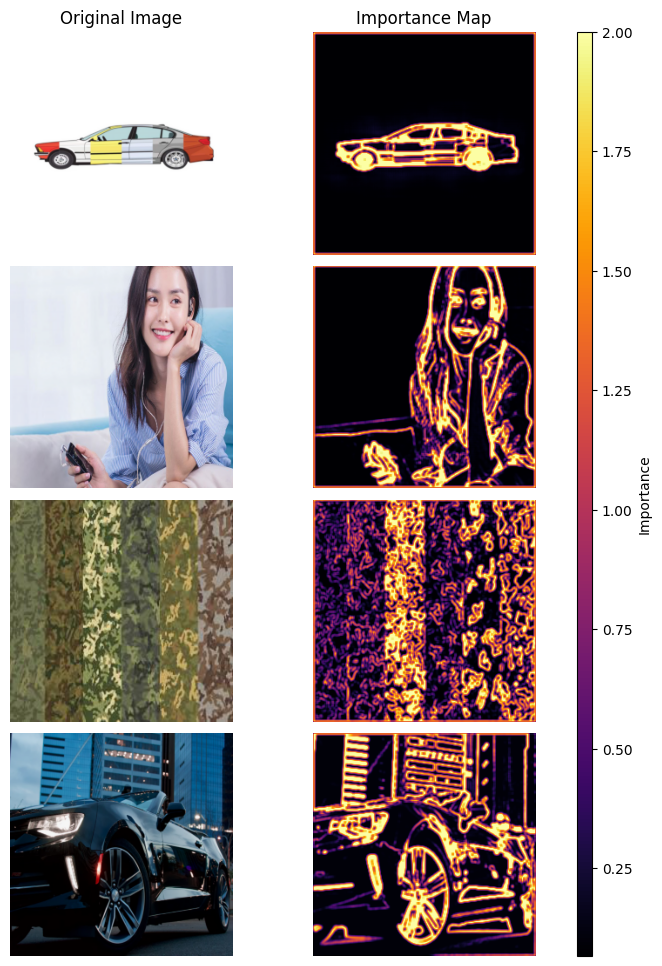

In [ ]:
num_samples = 4
indices = np.random.choice(len(test_hr), num_samples, replace=False)

# Create figure with extra column for colorbar
fig = plt.figure(figsize=(8, num_samples * 3))
gs = fig.add_gridspec(num_samples, 3, width_ratios=[1, 1, 0.05])

axes = []

for i, idx in enumerate(indices):
    hr = test_hr[idx]
    lr = test_lr[idx]
    pred = predict_map(hr, lr)

    ax1 = fig.add_subplot(gs[i, 0])
    ax2 = fig.add_subplot(gs[i, 1])

    # HR image
    ax1.imshow(hr)
    ax1.axis("off")

    # Importance map
    im = ax2.imshow(pred, cmap='inferno')
    ax2.axis("off")

    axes.append((ax1, ax2))

# Titles (only once)
axes[0][0].set_title("Original Image", fontsize=12)
axes[0][1].set_title("Importance Map", fontsize=12)

# Dedicated colorbar axis (no overlap)
cax = fig.add_subplot(gs[:, 2])
cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Importance", fontsize=10)

# Tight but controlled spacing
plt.subplots_adjust(wspace=0.02, hspace=0.05)

fig.savefig("/content/drive/MyDrive/imagecompression/importance_grid.png",
            dpi=150, bbox_inches='tight')

plt.show()

# Training Convergence Visualization

Plots training and validation loss over epochs to analyze how the model learns over time. This helps verify convergence, detect overfitting, and assess overall training stability.

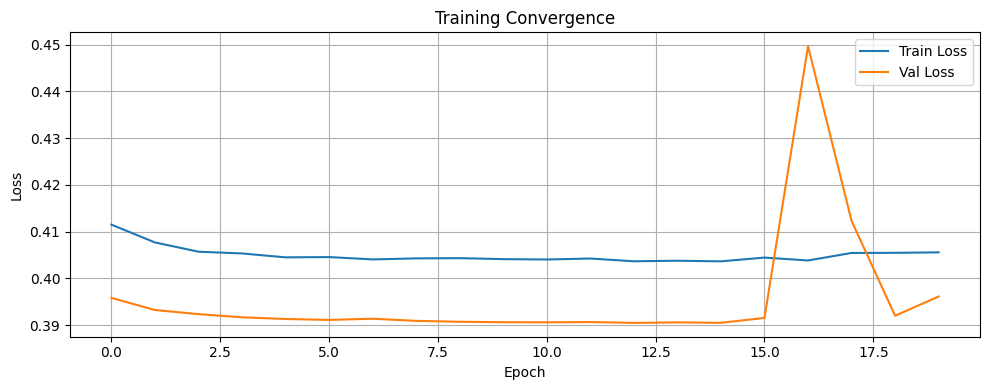

In [ ]:
# Load saved loss values
train_losses = np.load("/content/drive/MyDrive/imagecompression/train_losses.npy")
val_losses = np.load("/content/drive/MyDrive/imagecompression/val_losses.npy")

# Plot loss curves
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Convergence')
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig("/content/drive/MyDrive/imagecompression/training_convergence.png",
            dpi=150, bbox_inches='tight')

plt.show()

# Importing Compression Utilities

Evaluates the trained model on test images by generaing importance maps and visualizing where the model focuses. Used to verify that the model model correctly highlights visually significant regions for adaptive compression.

In [ ]:
#Adds the project directory to the Python path to enable importing custom utility functions.

import sys
sys.path.append('/content/drive/MyDrive/imagecompression')
import compression_utils as cu

# Adaptive vs Standard JPEG (Visual Comparison)

Evaluates compression on a selected image by comparing standard JPEG with the adaptive method. The adaptive approach uses the importance map to preserve high-detail regions (like skyline edges and reflections), resulting in slightly better visual quality and PSNR at a similar bitrate.

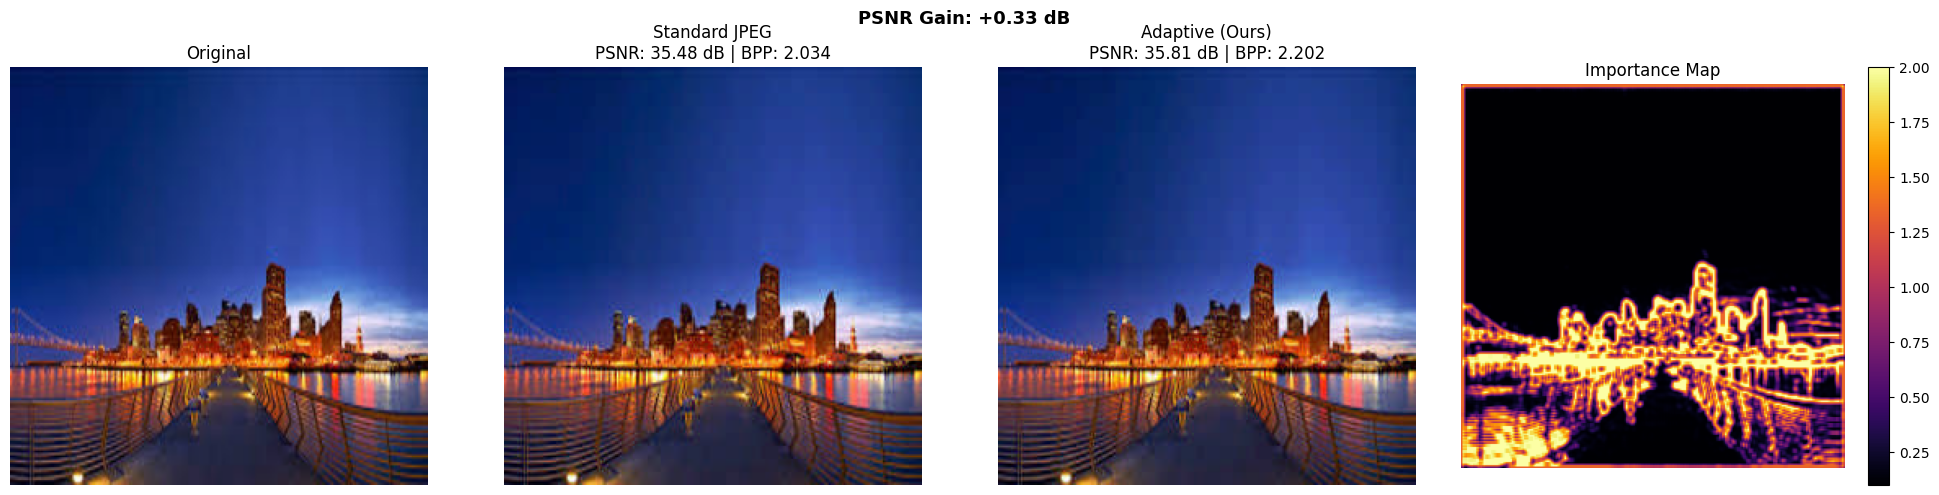

In [31]:
idx = 120

hr = test_hr[idx]
lr = test_lr[idx]

imp = predict_map(hr, lr)  # generate importance map

# Apply compression
compressed_adp, bits_adp = cu.process_image_bitrate_neutral(hr, 40, imp, alpha=1.0)
compressed_std, bits_std = cu.process_image_standard(hr, 40)

# Compute metrics
psnr_adp = 20 * np.log10(255.0 / cu.calculate_rmse(hr, compressed_adp))
psnr_std = 20 * np.log10(255.0 / cu.calculate_rmse(hr, compressed_std))

bpp_adp = bits_adp / (hr.shape[0] * hr.shape[1])
bpp_std = bits_std / (hr.shape[0] * hr.shape[1])

# Visualization
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(hr)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(compressed_std)
axes[1].set_title(f"Standard JPEG\nPSNR: {psnr_std:.2f} dB | BPP: {bpp_std:.3f}")
axes[1].axis("off")

axes[2].imshow(compressed_adp)
axes[2].set_title(f"Adaptive (Ours)\nPSNR: {psnr_adp:.2f} dB | BPP: {bpp_adp:.3f}")
axes[2].axis("off")

im = axes[3].imshow(imp, cmap='inferno')
axes[3].set_title("Importance Map")
axes[3].axis("off")

plt.colorbar(im, ax=axes[3])  # show importance scale

# Display gain
plt.suptitle(f"PSNR Gain: +{psnr_adp - psnr_std:.2f} dB", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/imagecompression/comparison.png", dpi=150)
plt.show()

# Quantitative Evaluation on Test Set

The adaptive compression method is evaluated against standard JPEG across 100 test images using RMSE, PSNR, BPP, and SSIM.

Results show that the adaptive approach improves reconstruction quality in 85 out of 100 images, achieving an average PSNR gain of +0.16 dB. While the adaptive method uses slightly higher bitrate (2.866 vs 2.783 BPP), it consistently preserves important details more effectively, leading to lower RMSE and higher PSNR.

SSIM remains nearly identical for both methods, indicating that perceptual quality is maintained while redistributing bits toward visually important regions.

In [34]:
from pytorch_msssim import ssim as ssim_fn

# SSIM computation
def calculate_ssim(original, compressed):
    orig_t = torch.from_numpy(original).permute(2,0,1).unsqueeze(0).float() / 255.0
    comp_t = torch.from_numpy(compressed).permute(2,0,1).unsqueeze(0).float() / 255.0
    return ssim_fn(orig_t, comp_t, data_range=1.0).item()

# Lists to store metrics
rmse_list, bpp_list, ssim_list = [], [], []
std_rmse_list, std_bpp_list, std_ssim_list = [], [], []

# Evaluate on test set
for i in tqdm(range(min(100, len(test_hr)))):
    hr = test_hr[i]
    lr = test_lr[i]

    imp = predict_map(hr, lr)

    # Adaptive compression
    compressed, bits = cu.process_image_bitrate_neutral(hr, 40, imp, alpha=1.0)
    rmse_list.append(cu.calculate_rmse(hr, compressed))
    bpp_list.append(bits / (hr.shape[0] * hr.shape[1]))
    ssim_list.append(calculate_ssim(hr, compressed))

    # Standard JPEG
    std_img, std_bits = cu.process_image_standard(hr, 40)
    std_rmse_list.append(cu.calculate_rmse(hr, std_img))
    std_bpp_list.append(std_bits / (hr.shape[0] * hr.shape[1]))
    std_ssim_list.append(calculate_ssim(hr, std_img))

# Compute PSNR correctly (per-image → then average)
psnr_list = [20 * np.log10(255.0 / r) for r in rmse_list]
std_psnr_list = [20 * np.log10(255.0 / r) for r in std_rmse_list]

# Compute gains
psnr_gains = np.array(psnr_list) - np.array(std_psnr_list)

# Print improvement stats
print("\nImages Improved:", np.sum(psnr_gains > 0), "/", len(psnr_gains))
print("Avg PSNR Gain:", np.mean(psnr_gains))

# Final summary
print(f"\nAdaptive  | RMSE: {np.mean(rmse_list):.3f} | BPP: {np.mean(bpp_list):.3f} | PSNR: {np.mean(psnr_list):.2f} dB | SSIM: {np.mean(ssim_list):.4f}")
print(f"Standard  | RMSE: {np.mean(std_rmse_list):.3f} | BPP: {np.mean(std_bpp_list):.3f} | PSNR: {np.mean(std_psnr_list):.2f} dB | SSIM: {np.mean(std_ssim_list):.4f}")

100%|██████████| 100/100 [01:29<00:00,  1.12it/s]


Images Improved: 85 / 100
Avg PSNR Gain: 0.15634651568710248

Adaptive  | RMSE: 4.857 | BPP: 2.866 | PSNR: 34.68 dB | SSIM: 0.9255
Standard  | RMSE: 4.933 | BPP: 2.783 | PSNR: 34.52 dB | SSIM: 0.9256


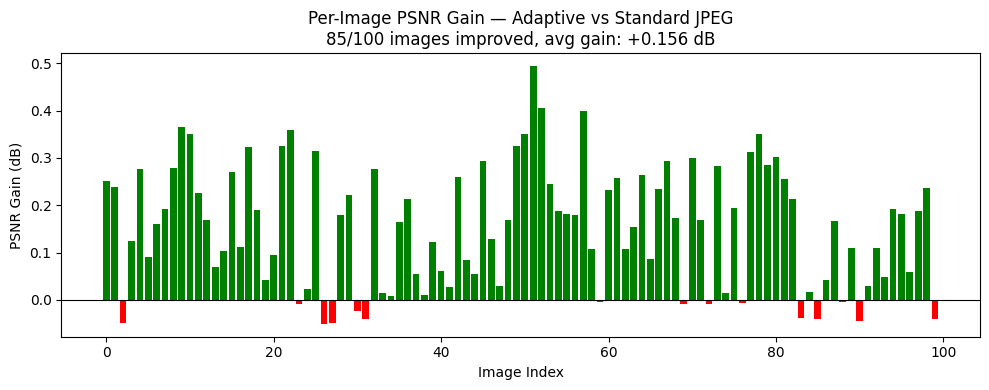

In [36]:
psnr_gains = []

# Compute PSNR gain per image
for r, sr in zip(rmse_list, std_rmse_list):
    gain = 20*np.log10(255.0/r) - 20*np.log10(255.0/sr)
    psnr_gains.append(gain)

# Create bar plot
plt.figure(figsize=(10, 4))

plt.bar(
    range(len(psnr_gains)),
    psnr_gains,
    color=['green' if g > 0 else 'red' for g in psnr_gains]  # green = improved, red = worse
)

# Reference line (no gain)
plt.axhline(y=0, color='black', linewidth=0.8)

# Labels and title
plt.xlabel('Image Index')
plt.ylabel('PSNR Gain (dB)')
plt.title(
    f'Per-Image PSNR Gain — Adaptive vs Standard JPEG\n'
    f'{sum(g > 0 for g in psnr_gains)}/100 images improved, '
    f'avg gain: +{np.mean(psnr_gains):.3f} dB'
)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/imagecompression/psnr_gain_bar.png",
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# Importance vs Compression Error Correlation

The importance-error correlation of 0.46 indicates that the model successfully identifies regions where compression error is higher. This confirms that the learned importance maps align with difficult-to-compress areas, validating the effectiveness of the training process.

In [38]:
def compression_error_map(original, compressed):
    # Compute per-pixel reconstruction error
    err = np.abs(original.astype(float) - compressed.astype(float)).mean(axis=2)

    # Normalize for comparison
    return err / (err.max() + 1e-6)

corr_list = []

# Evaluate correlation on subset of test images
for i in range(min(20, len(test_hr))):
    hr = test_hr[i]
    lr = test_lr[i]

    imp = predict_map(hr, lr)  # predicted importance
    std_img, _ = cu.process_image_standard(hr, 40)  # standard JPEG output

    err_map = compression_error_map(hr, std_img)  # actual error

    # Correlation between importance and error
    corr = np.corrcoef(imp.flatten(), err_map.flatten())[0, 1]
    corr_list.append(corr)

# Average correlation
print(f"Importance-Error Correlation: {np.mean(corr_list):.4f}")

Importance-Error Correlation: 0.4634


## Download Results File from Google Colab

In [39]:
import json

results = {
    "adaptive_rmse": float(np.mean(rmse_list)),
    "adaptive_bpp": float(np.mean(bpp_list)),
    "adaptive_psnr": float(np.mean(psnr_list)),
    "adaptive_ssim": float(np.mean(ssim_list)),
    "standard_rmse": float(np.mean(std_rmse_list)),
    "standard_bpp": float(np.mean(std_bpp_list)),
    "standard_psnr": float(np.mean(std_psnr_list)),
    "standard_ssim": float(np.mean(std_ssim_list)),
    "images_improved": int(sum(g > 0 for g in psnr_gains)),
    "total_images": len(psnr_gains),
    "avg_psnr_gain": float(np.mean(psnr_gains)),
    "importance_error_correlation": float(np.mean(corr_list))
}

with open("/content/drive/MyDrive/imagecompression/test_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Results saved.")

Results saved.
